## 1. Data Loading

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

folder_path= Path(r"C:\Users\Mohammed\Desktop\Work\Cyclistic-Case-Study\data_raw\excel\Raw")
files= folder_path.glob("2025*-divvy-tripdata.csv")

df= pd.concat((pd.read_csv(file) for file  in files), ignore_index = True)
df.shape

(5552994, 13)

## 2. Data Cleaning

In [74]:
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"]= pd.to_datetime(df["ended_at"])

## 3. Feature Engineering 

In [75]:
df["ride_length"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

In [76]:
## Remove rides shorter than 1 minute
df= df[df["ride_length"] > 1].copy() 

In [77]:
df["day_of_week"]= df["started_at"].dt.dayofweek + 1

In [78]:
df["month"]= df["started_at"].dt.month

In [79]:
df["month_name"]= df["started_at"].dt.strftime("%b")

In [80]:
df["day_of_week_name"]= df["started_at"].dt.strftime("%a")

## 4. Exploratory Analysis

In [81]:
df["member_casual"].value_counts()

member_casual
member    3485109
casual    1920483
Name: count, dtype: int64

In [82]:
df.groupby("member_casual")["ride_length"].mean()

member_casual
casual    23.509521
member    12.567110
Name: ride_length, dtype: float64

In [83]:
df.groupby(["member_casual" , "day_of_week"])["ride_length"].agg(["mean", "count"])

mean   count
member_casual day_of_week                   
casual        1            23.180322  219749
              2            20.594990  217363
              3            19.434497  213186
              4            20.591954  248420
              5            23.428453  307258
              6            26.357287  396657
              7            27.268194  317850
member        1            12.103732  493437
              2            12.171150  552650
              3            11.992008  540345
              4            12.114824  565325
              5            12.514136  518680
              6            13.787481  440019
              7            13.913440  374653

In [84]:
# Count of rides by user type and day of week
day_counts = df.groupby(["member_casual", "day_of_week"])["ride_id"].count().reset_index()
day_counts.columns = ["member_casual", "day_of_week", "ride_count"]

# Map day numbers to names for readability
day_names = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
day_counts["day_name"] = day_counts["day_of_week"].map(day_names)

print(day_counts)

   member_casual  day_of_week  ride_count day_name
0         casual            1      219749      Mon
1         casual            2      217363      Tue
2         casual            3      213186      Wed
3         casual            4      248420      Thu
4         casual            5      307258      Fri
5         casual            6      396657      Sat
6         casual            7      317850      Sun
7         member            1      493437      Mon
8         member            2      552650      Tue
9         member            3      540345      Wed
10        member            4      565325      Thu
11        member            5      518680      Fri
12        member            6      440019      Sat
13        member            7      374653      Sun


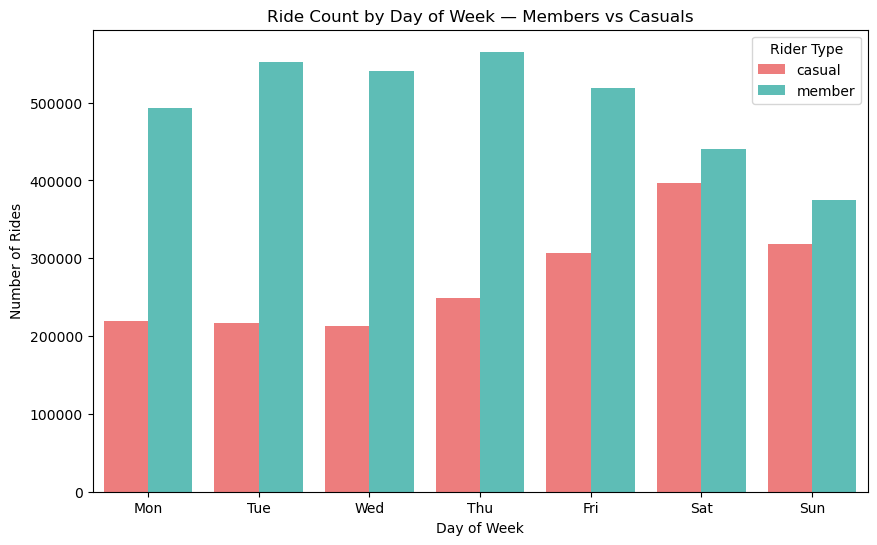

In [85]:
plt.figure(figsize=(10, 6))
sns.barplot(data=day_counts, x="day_name", y="ride_count", hue="member_casual",
            order=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],
            palette={"casual": "#FF6B6B", "member": "#4ECDC4"})  

plt.title("Ride Count by Day of Week — Members vs Casuals")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")
plt.legend(title="Rider Type")
plt.savefig("ride_count_by_day.png", dpi=300, bbox_inches="tight")  
plt.show()

In [86]:
# Count of rides by user type and month
month_counts = df.groupby(["member_casual", "month"])["ride_id"].count().reset_index()
month_counts.columns = ["member_casual", "month", "ride_count"]

# Map month numbers to names
month_names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
               7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}
month_counts["month_name"] = month_counts["month"].map(month_names)

print(month_counts)

   member_casual  month  ride_count month_name
0         casual      1       23453        Jan
1         casual      2       27051        Feb
2         casual      3       83064        Mar
3         casual      4      105528        Apr
4         casual      5      176162        May
5         casual      6      279570        Jun
6         casual      7      309293        Jul
7         casual      8      324165        Aug
8         casual      9      255223        Sep
9         casual     10      214849        Oct
10        casual     11       94930        Nov
11        casual     12       27195        Dec
12        member      1      112352        Jan
13        member      2      122118        Feb
14        member      3      208500        Mar
15        member      4      257962        Apr
16        member      5      314091        May
17        member      6      379609        Jun
18        member      7      430535        Jul
19        member      8      443214        Aug
20        mem

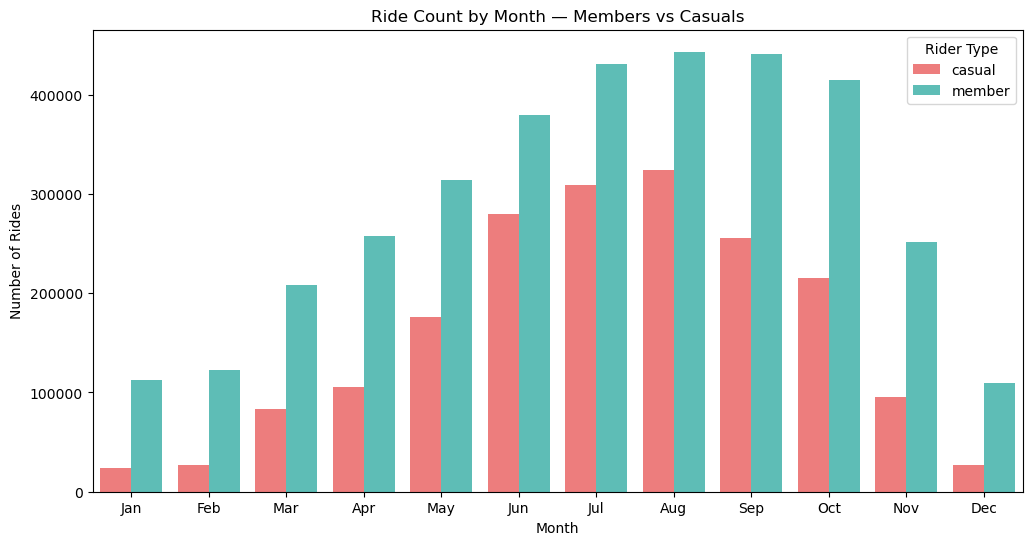

In [87]:
plt.figure(figsize=(12, 6))
sns.barplot(data=month_counts, x="month_name", y="ride_count", hue="member_casual",
            order=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            palette={"casual": "#FF6B6B", "member": "#4ECDC4"})  

plt.title("Ride Count by Month — Members vs Casuals")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.legend(title="Rider Type")
plt.savefig("ride_count_by_month.png", dpi=300, bbox_inches="tight")
plt.show()


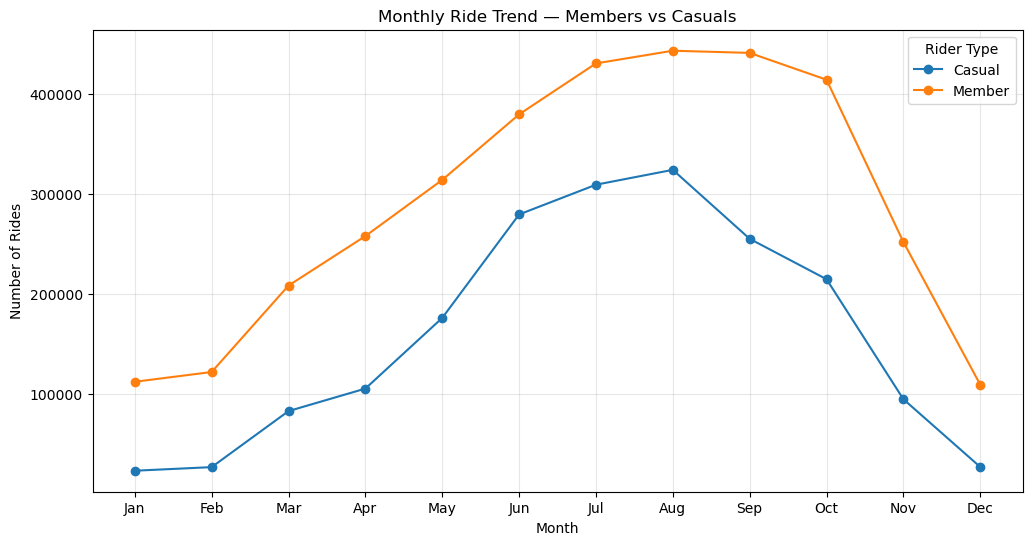

In [88]:
pivot = month_counts.pivot(index="month", columns="member_casual", values="ride_count")

plt.figure(figsize=(12, 6))
plt.plot(pivot.index, pivot["casual"], marker="o", label="Casual")
plt.plot(pivot.index, pivot["member"], marker="o", label="Member")

plt.xticks(ticks=range(1,13), labels=["Jan","Feb","Mar","Apr","May","Jun",
                                       "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.title("Monthly Ride Trend — Members vs Casuals")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.legend(title="Rider Type")
plt.grid(True, alpha=0.3)
plt.show()

In [89]:
# Map months to seasons
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",   10: "Fall",  11: "Fall"
}

df["season"] = df["month"].map(season_map)

# Count rides by season and member type
season_counts = df.groupby(["member_casual", "season"])["ride_id"].count().reset_index()
season_counts.columns = ["member_casual", "season", "ride_count"]

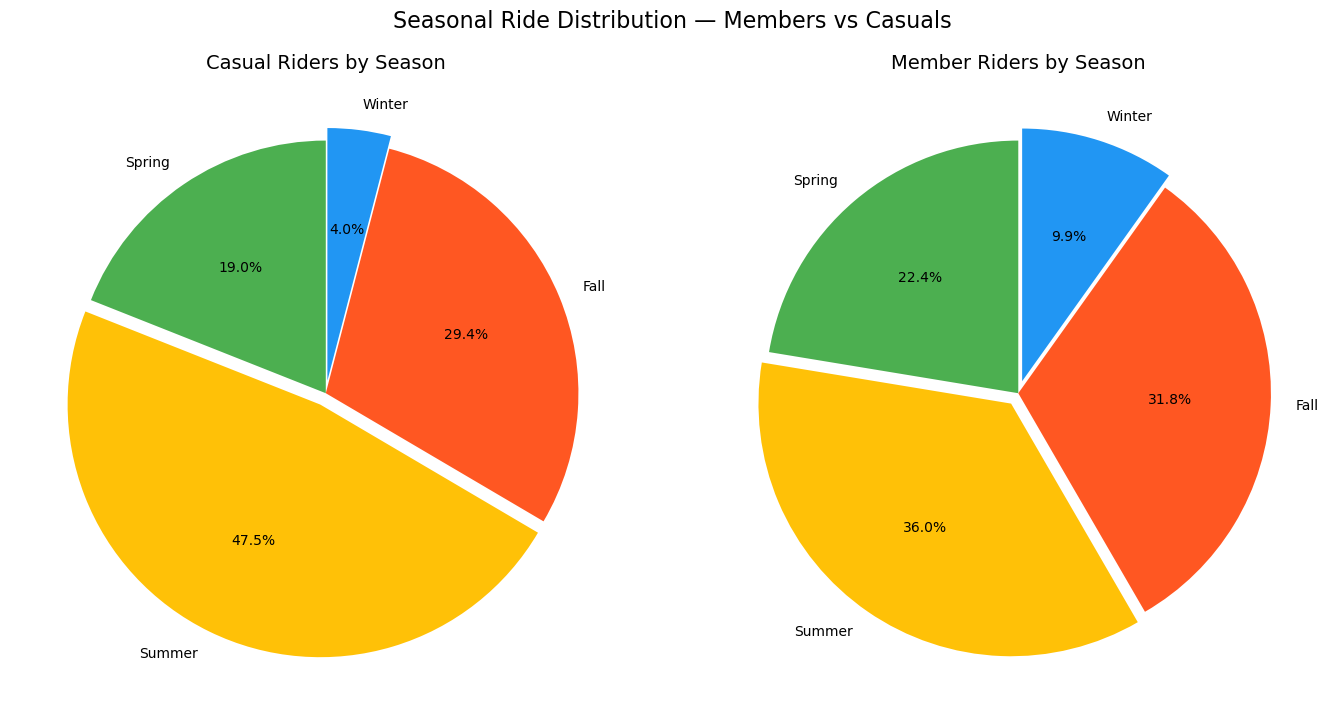

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

season_order = ["Spring", "Summer", "Fall", "Winter"]
colors = ["#4CAF50", "#FFC107", "#FF5722", "#2196F3"]

for ax, rider_type in zip(axes, ["casual", "member"]):
    data = season_counts[season_counts["member_casual"] == rider_type]
    data = data.set_index("season").reindex(season_order)
    
    ax.pie(data["ride_count"], 
           labels=season_order, 
           colors=colors,
           autopct="%1.1f%%", 
           startangle=90,
           explode=(0, 0.05, 0, 0.05))  
    
    ax.set_title(f"{rider_type.capitalize()} Riders by Season", fontsize=14)

plt.suptitle("Seasonal Ride Distribution — Members vs Casuals", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## This was left out of the analysis because it's out of scope for this analysis ##

In [91]:
summer = df[df["season"] == "Summer"].groupby("member_casual")["ride_id"].count()
winter = df[df["season"] == "Winter"].groupby("member_casual")["ride_id"].count()

drop_pct = ((summer - winter) / summer * 100).round(1)
print(drop_pct)

member_casual
casual    91.5
member    72.6
Name: ride_id, dtype: float64


In [92]:
# Extract hour from started_at
df["hour"] = df["started_at"].dt.hour

# Count rides by hour and member type
hour_counts = df.groupby(["member_casual", "hour"])["ride_id"].count().reset_index()
hour_counts.columns = ["member_casual", "hour", "ride_count"]

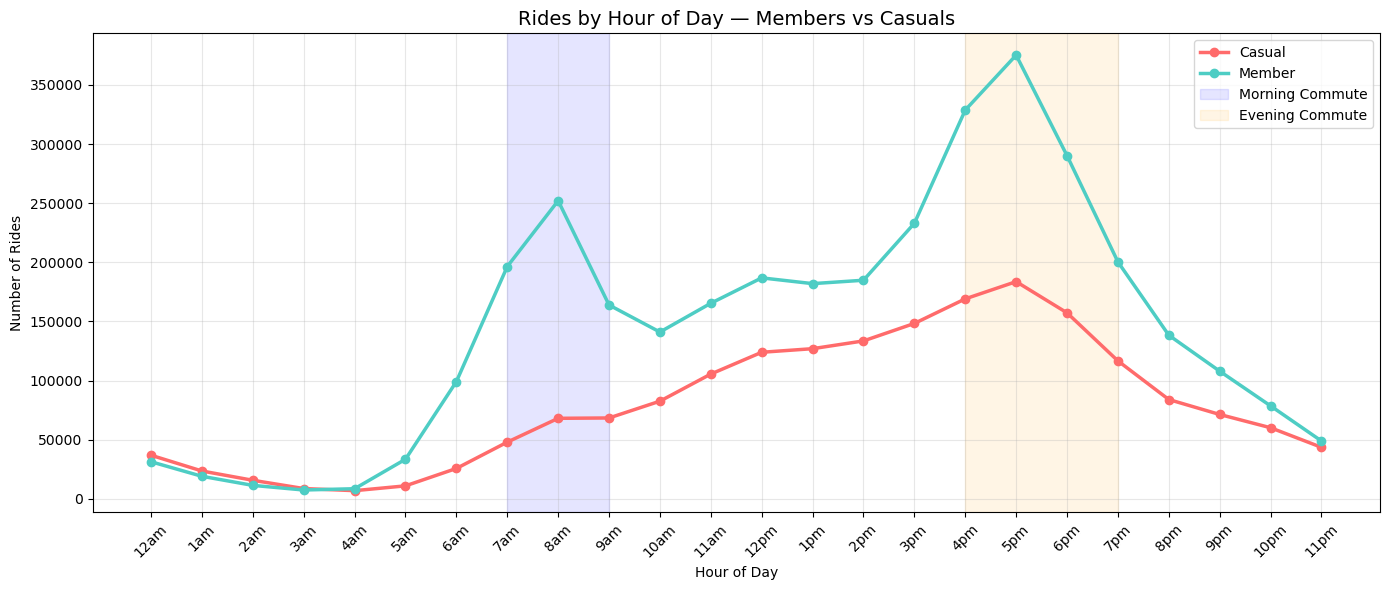

In [93]:
plt.figure(figsize=(14, 6))

for rider_type, color in zip(["casual", "member"], ["#FF6B6B", "#4ECDC4"]):
    data = hour_counts[hour_counts["member_casual"] == rider_type]
    plt.plot(data["hour"], data["ride_count"], 
             marker="o", label=rider_type.capitalize(), 
             color=color, linewidth=2.5)

# Shade commute hours
plt.axvspan(7, 9, alpha=0.1, color="blue", label="Morning Commute")
plt.axvspan(16, 19, alpha=0.1, color="orange", label="Evening Commute")

plt.xticks(range(0, 24), 
           ["12am","1am","2am","3am","4am","5am","6am","7am","8am","9am","10am","11am",
            "12pm","1pm","2pm","3pm","4pm","5pm","6pm","7pm","8pm","9pm","10pm","11pm"],
           rotation=45)

plt.title("Rides by Hour of Day — Members vs Casuals", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rides_by_hour_of_day", dpi=300, bbox_inches="tight")
plt.show()

In [94]:
# Average ride length by member type
avg_ride_length = df.groupby("member_casual")["ride_length"].mean().reset_index()
avg_ride_length.columns = ["member_casual", "avg_ride_length"]
avg_ride_length["avg_ride_length"] = avg_ride_length["avg_ride_length"].round(2)

print(avg_ride_length)

  member_casual  avg_ride_length
0        casual            23.51
1        member            12.57


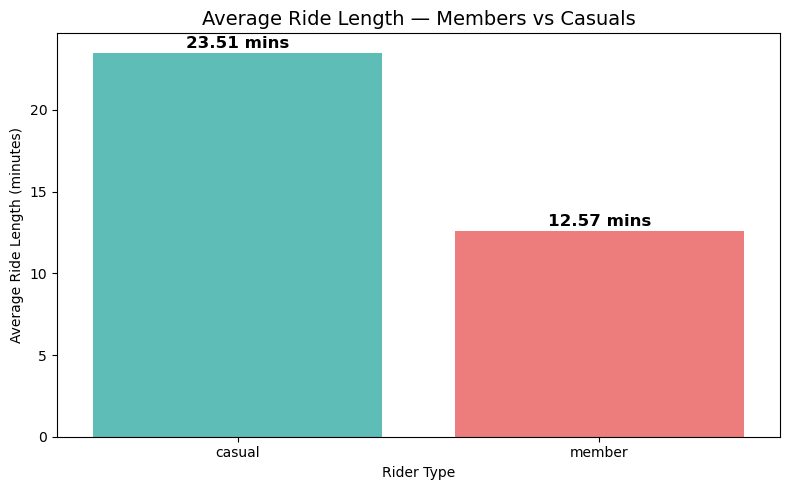

In [95]:
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_ride_length, x="member_casual", y="avg_ride_length",
            hue="member_casual", palette=["#4ECDC4", "#FF6B6B"], legend=False)

# Add value labels on top of bars
for i, row in avg_ride_length.iterrows():
    plt.text(i, row["avg_ride_length"] + 0.3, 
             f"{row['avg_ride_length']} mins", 
             ha="center", fontsize=12, fontweight="bold")

plt.title("Average Ride Length — Members vs Casuals", fontsize=14)
plt.xlabel("Rider Type")
plt.ylabel("Average Ride Length (minutes)")
plt.tight_layout()
plt.savefig("avg_ride_length.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Key Insights
- Casual riders take longer rides on average
- Members ride more frequently but for shorter durations
- Weekend usage is higher for casual riders 